In [58]:
import pandas as pd
df = pd.read_csv('Employee.csv')
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


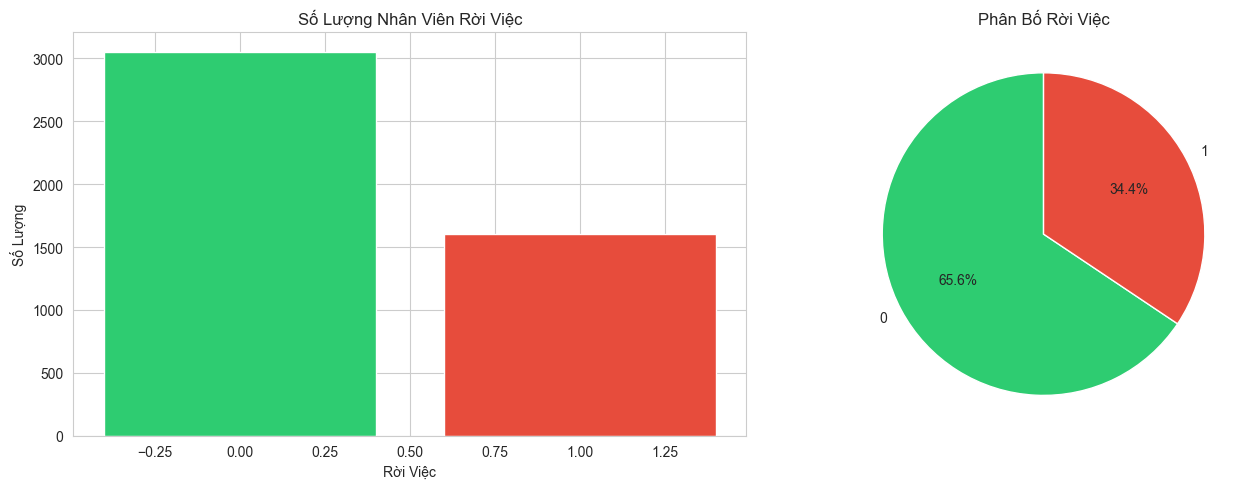

In [59]:
import matplotlib.pyplot as plt

attrition_counts = df['LeaveOrNot'].value_counts()

labels = attrition_counts.index
values = attrition_counts.values
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(14, 5))

# ===== Biểu đồ cột =====
plt.subplot(1, 2, 1)
plt.bar(labels, values, color=colors)
plt.title('Số Lượng Nhân Viên Rời Việc')
plt.xlabel('Rời Việc')
plt.ylabel('Số Lượng')

# ===== Biểu đồ tròn =====
plt.subplot(1, 2, 2)
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Phân Bố Rời Việc')

plt.tight_layout()
plt.show()


In [60]:
# Chuẩn hóa cột target để phù hợp với cấu trúc báo cáo
candidate_targets = ['LeaveOrNot','Attrition','Leave','Left','LeftCompany','Resigned']
found = None
for c in candidate_targets:
    if c in df.columns:
        s = df[c]
        if pd.api.types.is_numeric_dtype(s):
            vals = set(s.dropna().unique())
            if vals <= {0, 1}:
                df['LeaveOrNot'] = s.map({1: 'Yes', 0: 'No'})
            else:
                maxval = s.max()
                df['LeaveOrNot'] = s.apply(lambda x: 'Yes' if x == maxval else 'No')
        else:
            df['LeaveOrNot'] = s.astype(str).apply(lambda v: 'Yes' if str(v).strip().lower() in ['yes','y','true','1','t'] else 'No')
        found = c
        break

In [61]:
# Bổ sung cột nhị phân 'target' = 1 (Yes), 0 (No)
df['target'] = (df['LeaveOrNot'] == 'Yes').astype(int)
print(f"Target derived from column: {found}")
print(df['LeaveOrNot'].value_counts())
print(df['target'].value_counts())

Target derived from column: LeaveOrNot
LeaveOrNot
No     3053
Yes    1600
Name: count, dtype: int64
target
0    3053
1    1600
Name: count, dtype: int64


In [62]:
print('\n--- EDA nhanh ---')
print('Kích thước dữ liệu:', df.shape)
print('\nGiá trị thiếu theo cột:')
print(df.isnull().sum())



--- EDA nhanh ---
Kích thước dữ liệu: (4653, 10)

Giá trị thiếu theo cột:
Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
target                       0
dtype: int64


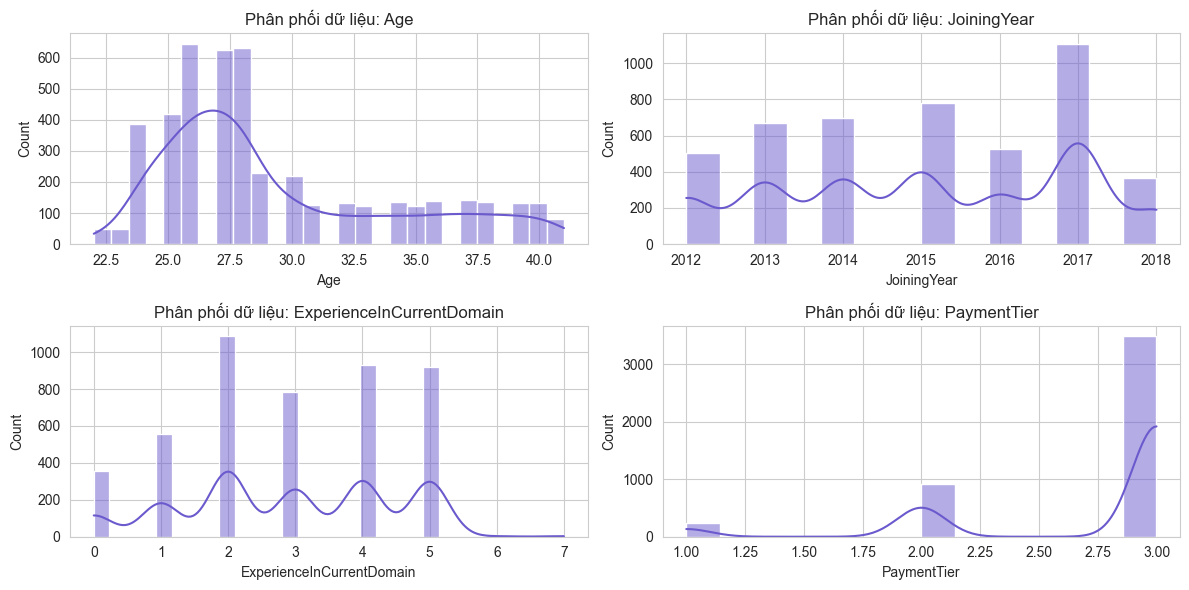

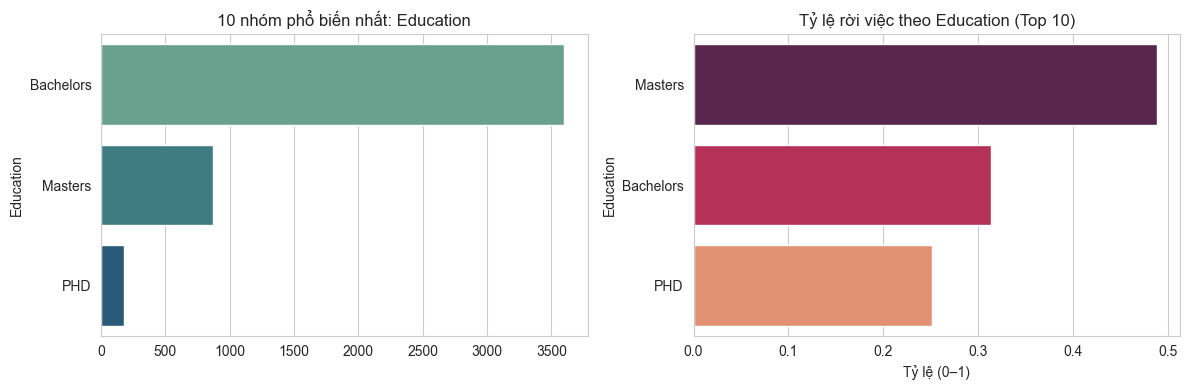

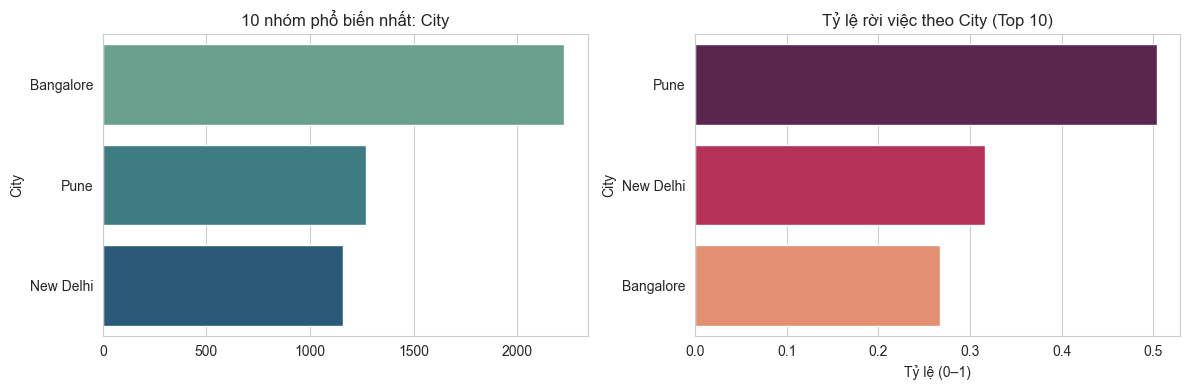

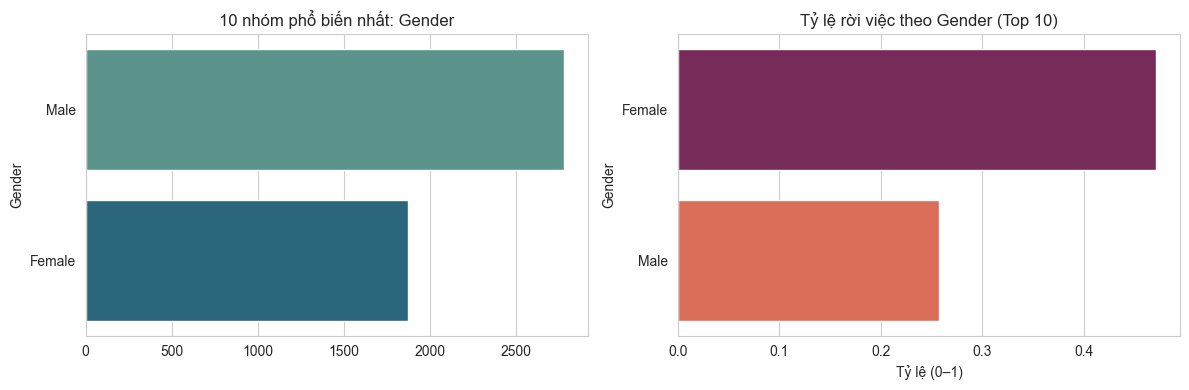

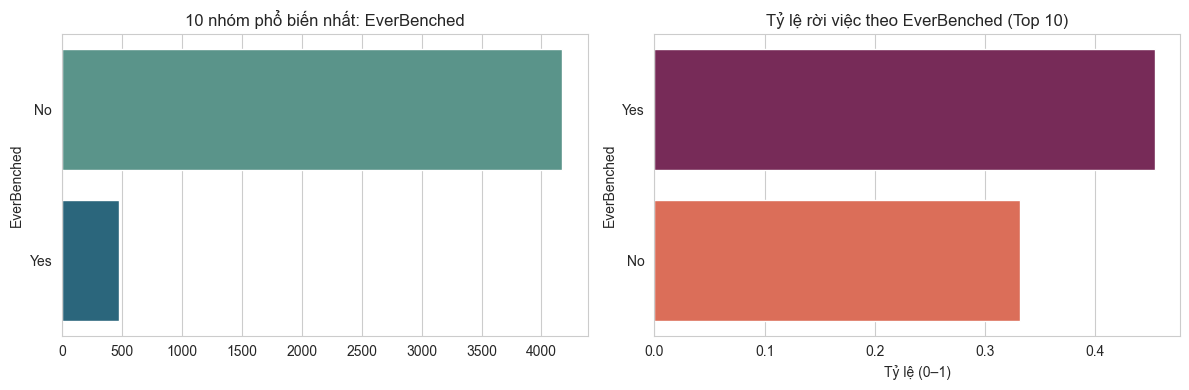

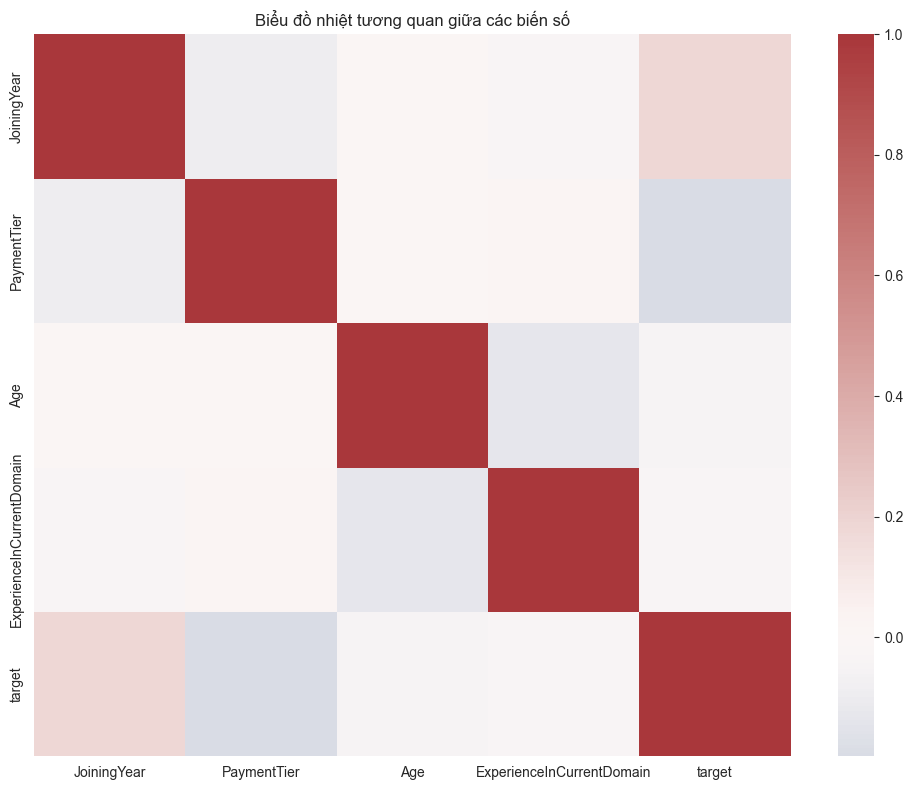

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_style('whitegrid')

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
missing = df.isnull().sum().sort_values(ascending=False)

if missing.max() > 0:
    plt.figure(figsize=(8, max(2, 0.25 * len(missing))))
    missing[missing > 0].plot(kind='barh', color='tomato')
    plt.title('Số lượng giá trị thiếu theo từng cột')
    plt.xlabel('Số lượng')
    plt.tight_layout()
    plt.show()

if len(num_cols) > 0:
    var_sorted = df[num_cols].var().sort_values(ascending=False).index.tolist()
    plot_cols = var_sorted[:4]

    fig, axes = plt.subplots(
        len(plot_cols)//2 + len(plot_cols)%2, 
        2, 
        figsize=(12, 3 * (len(plot_cols)//2 + len(plot_cols)%2))
    )
    axes = axes.ravel()

    for ax, col in zip(axes, plot_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=ax, color='slateblue')
        ax.set_title(f'Phân phối dữ liệu: {col}')

    plt.tight_layout()
    plt.show()

if len(cat_cols) > 0:
    plot_cats = cat_cols[:4]

    for col in plot_cats:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Biểu đồ tần suất xuất hiện (Top 10)
        counts = df[col].value_counts().nlargest(10)
        sns.barplot(x=counts.values, y=counts.index, ax=ax1, palette='crest', hue=counts.index, legend=False)
        ax1.set_title(f'10 nhóm phổ biến nhất: {col}')

        # Biểu đồ tỷ lệ rời việc theo nhóm (nếu có target)
        if 'target' in df.columns:
            rate = df.groupby(col)['target'].mean().sort_values(ascending=False).head(10)
            sns.barplot(x=rate.values, y=rate.index, ax=ax2, palette='rocket', hue=rate.index, legend=False)
            ax2.set_title(f'Tỷ lệ rời việc theo {col} (Top 10)')
            ax2.set_xlabel('Tỷ lệ (0–1)')

        plt.tight_layout()
        plt.show()


if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    corr = df[num_cols].corr()
    sns.heatmap(corr, cmap='vlag', center=0, annot=False, fmt='.2f')
    plt.title('Biểu đồ nhiệt tương quan giữa các biến số')
    plt.tight_layout()
    plt.show()


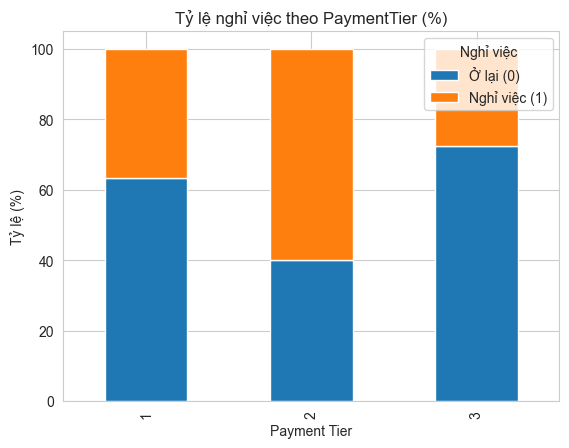

In [64]:
# Tính tỷ lệ %
ct = pd.crosstab(
    df["PaymentTier"],
    df["LeaveOrNot"],
    normalize="index"
) * 100

ct.plot(
    kind="bar",
    stacked=True
)

plt.title("Tỷ lệ nghỉ việc theo PaymentTier (%)")
plt.xlabel("Payment Tier")
plt.ylabel("Tỷ lệ (%)")
plt.legend(title="Nghỉ việc", labels=["Ở lại (0)", "Nghỉ việc (1)"])
plt.show()


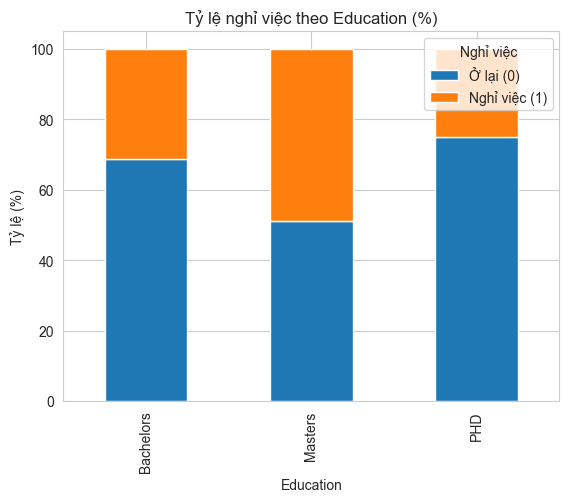

In [65]:
# Tính tỷ lệ %
ct = pd.crosstab(
    df["Education"],
    df["LeaveOrNot"],
    normalize="index"
) * 100

ct.plot(
    kind="bar",
    stacked=True
)

plt.title("Tỷ lệ nghỉ việc theo Education (%)")
plt.xlabel("Education")
plt.ylabel("Tỷ lệ (%)")
plt.legend(title="Nghỉ việc", labels=["Ở lại (0)", "Nghỉ việc (1)"])
plt.show()


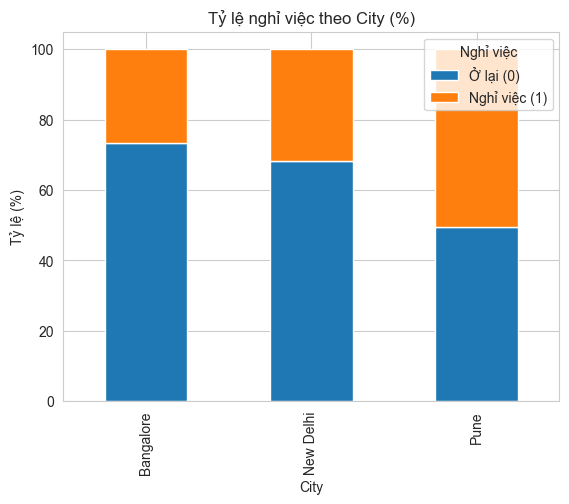

In [66]:
# Tính tỷ lệ %
ct = pd.crosstab(
    df["City"],
    df["LeaveOrNot"],
    normalize="index"
) * 100

ct.plot(
    kind="bar",
    stacked=True
)

plt.title("Tỷ lệ nghỉ việc theo City (%)")
plt.xlabel("City")
plt.ylabel("Tỷ lệ (%)")
plt.legend(title="Nghỉ việc", labels=["Ở lại (0)", "Nghỉ việc (1)"])
plt.show()


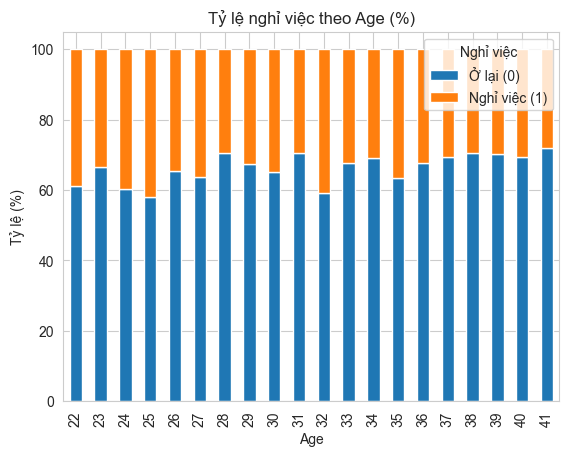

In [67]:
# Tính tỷ lệ %
ct = pd.crosstab(
    df["Age"],
    df["LeaveOrNot"],
    normalize="index"
) * 100

ct.plot(
    kind="bar",
    stacked=True
)

plt.title("Tỷ lệ nghỉ việc theo Age (%)")
plt.xlabel("Age")
plt.ylabel("Tỷ lệ (%)")
plt.legend(title="Nghỉ việc", labels=["Ở lại (0)", "Nghỉ việc (1)"])
plt.show()


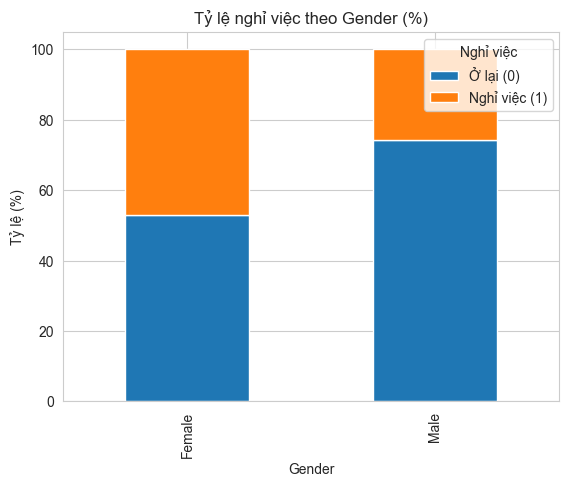

In [68]:
# Tính tỷ lệ %
ct = pd.crosstab(
    df["Gender"],
    df["LeaveOrNot"],
    normalize="index"
) * 100

ct.plot(
    kind="bar",
    stacked=True
)

plt.title("Tỷ lệ nghỉ việc theo Gender (%)")
plt.xlabel("Gender")
plt.ylabel("Tỷ lệ (%)")
plt.legend(title="Nghỉ việc", labels=["Ở lại (0)", "Nghỉ việc (1)"])
plt.show()


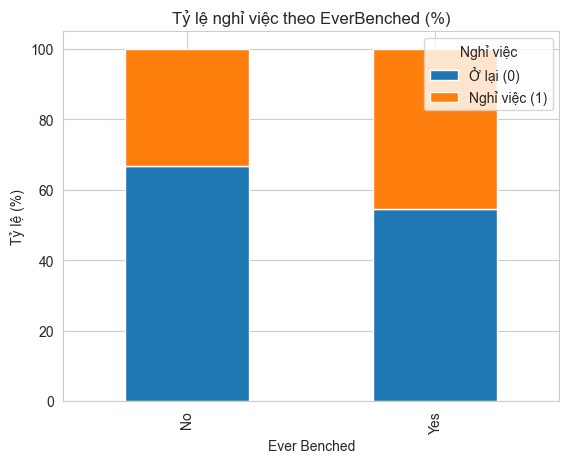

In [69]:
# Tính tỷ lệ %
ct = pd.crosstab(
    df["EverBenched"],
    df["LeaveOrNot"],
    normalize="index"
) * 100

ct.plot(
    kind="bar",
    stacked=True
)

plt.title("Tỷ lệ nghỉ việc theo EverBenched (%)")
plt.xlabel("Ever Benched")
plt.ylabel("Tỷ lệ (%)")
plt.legend(title="Nghỉ việc", labels=["Ở lại (0)", "Nghỉ việc (1)"])
plt.show()


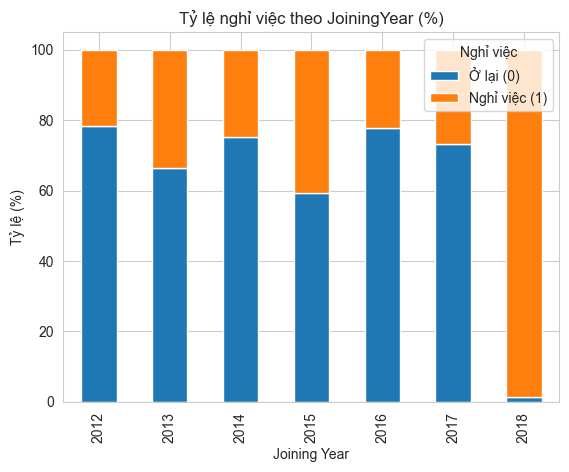

In [70]:
# Tính tỷ lệ %
ct = pd.crosstab(
    df["JoiningYear"],
    df["LeaveOrNot"],
    normalize="index"
) * 100

ct.plot(
    kind="bar",
    stacked=True
)

plt.title("Tỷ lệ nghỉ việc theo JoiningYear (%)")
plt.xlabel("Joining Year")
plt.ylabel("Tỷ lệ (%)")
plt.legend(title="Nghỉ việc", labels=["Ở lại (0)", "Nghỉ việc (1)"])
plt.show()


7448 931
Tâp test: target
0    611
1    320
Name: count, dtype: int64
Tập train: target
0    2442
1    1953
Name: count, dtype: int64


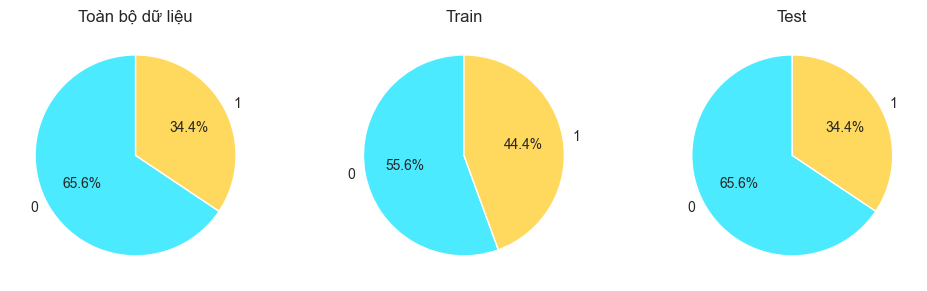

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Chuẩn bị dữ liệu cho mô hình

if 'df_model' not in globals():
    df_model = df.copy()

# Drop any original target columns to avoid data leakage
drop_cols = [c for c in ['target','LeaveOrNot','Attrition','Leave'] if c in df_model.columns]
label_encoders = {}
cat_cols = df_model.select_dtypes(include=['object','category']).columns.tolist()
for col in cat_cols:
    if col == 'LeaveOrNot':
        continue
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
X = df_model.drop(columns=drop_cols, errors='ignore')
y = df_model['target']

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

smote = SMOTE(
    sampling_strategy=0.8,
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


print('Tâp test:', y_test.value_counts())
print('Tập train:', y_train_res.value_counts())

fig, axes = plt.subplots(1, 3, figsize=(10,3))

datasets = [
    ('Toàn bộ dữ liệu', y),
    ('Train', y_train_res),
    ('Test', y_test)
]

for ax, (title, data) in zip(axes, datasets):
    ax.pie(
        data.value_counts(),
        labels=data.value_counts().index,
        autopct='%1.1f%%',
        startangle=90,
        colors=["#4beaff", "#ffd95e"],
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()



In [72]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score

# Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Logistic
lr = LogisticRegression(max_iter=2000, class_weight=None, random_state=42)
lr.fit(X_train_scaled, y_train_res)
y_pred_lr = lr.predict(X_test_scaled)
print('\nLogistic Regression:')
print(classification_report(y_test, y_pred_lr, digits=4))

# Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train_res)
y_pred_dt = dt.predict(X_test_scaled)
print('\nDecision Tree:')
print(classification_report(y_test, y_pred_dt, digits=4))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_res)
y_pred_rf = rf.predict(X_test_scaled)
print('\nRandom Forest:')
print(classification_report(y_test, y_pred_rf, digits=4))



Logistic Regression:
              precision    recall  f1-score   support

           0     0.7677    0.8003    0.7837       611
           1     0.5850    0.5375    0.5603       320

    accuracy                         0.7100       931
   macro avg     0.6763    0.6689    0.6720       931
weighted avg     0.7049    0.7100    0.7069       931


Decision Tree:
              precision    recall  f1-score   support

           0     0.8475    0.9002    0.8730       611
           1     0.7837    0.6906    0.7342       320

    accuracy                         0.8281       931
   macro avg     0.8156    0.7954    0.8036       931
weighted avg     0.8255    0.8281    0.8253       931


Random Forest:
              precision    recall  f1-score   support

           0     0.8437    0.8920    0.8671       611
           1     0.7684    0.6844    0.7240       320

    accuracy                         0.8206       931
   macro avg     0.8060    0.7882    0.7956       931
weighted avg     0.8

C:\Users\Acer\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\Acer\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


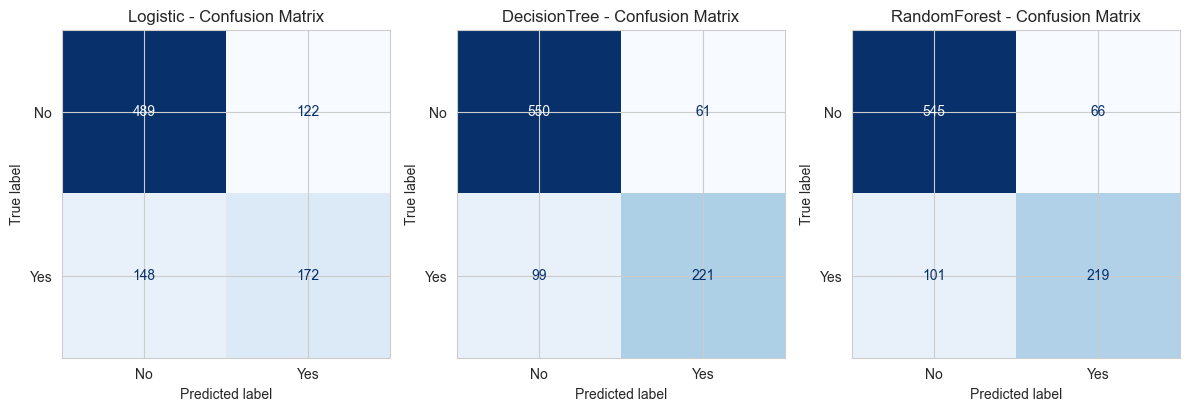

In [73]:
# Vẽ Confusion Matrix và Precision-Recall Curve cho các mô hình
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, average_precision_score

models = {
    'Logistic': (lr, X_test_scaled, lr.predict_proba(X_test_scaled)[:,1] if hasattr(lr, 'predict_proba') else None, y_pred_lr),
    'DecisionTree': (dt, X_test, dt.predict_proba(X_test)[:,1] if hasattr(dt, 'predict_proba') else None, y_pred_dt),
    'RandomForest': (rf, X_test, rf.predict_proba(X_test)[:,1] if hasattr(rf, 'predict_proba') else None, y_pred_rf),
}

# Confusion matrices (2x2)
fig, axes = plt.subplots(1, 3, figsize=(12, 10))
axes = axes.ravel()
for ax, (name, (model, X_in, y_score, y_pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} - Confusion Matrix')
plt.tight_layout()
plt.show()


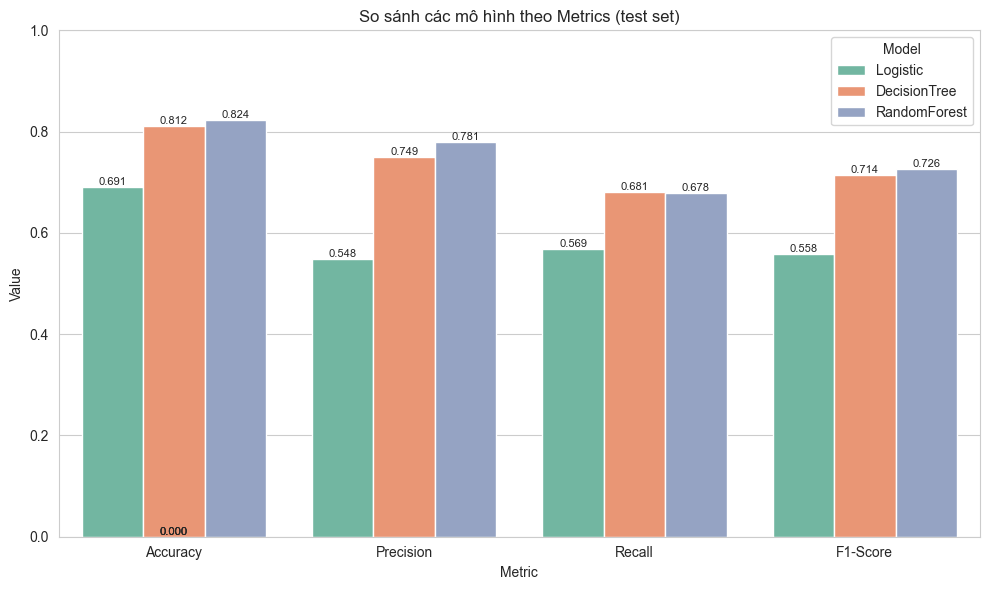


Bảng kết quả (test set):
       Model  Accuracy  Precision   Recall  F1-Score
    Logistic  0.690655   0.548193 0.568750  0.558282
DecisionTree  0.812030   0.749141 0.681250  0.713584
RandomForest  0.823845   0.780576 0.678125  0.725753


In [74]:
# Vẽ so sánh các metrics giữa các mô hình (grouped bar chart)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Ensure results_df exists
if 'results_df' not in globals():
    results = []
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    for name, y_pred in [('Logistic', y_pred_lr), ('DecisionTree', y_pred_dt), ('RandomForest', y_pred_rf)]:
        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-Score': f1_score(y_test, y_pred, zero_division=0)
        })
    results_df = pd.DataFrame(results)

# Melt for plotting
plot_df = results_df.melt(id_vars='Model', var_name='Metric', value_name='Value')
metric_order = ['Accuracy','Precision','Recall','F1-Score']
plot_df['Metric'] = pd.Categorical(plot_df['Metric'], categories=metric_order, ordered=True)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=plot_df, x='Metric', y='Value', hue='Model', palette='Set2')
ax.set_ylim(0,1)
ax.set_title('So sánh các mô hình theo Metrics (test set)')

# Annotate bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.3f}', (p.get_x()+p.get_width()/2., height), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title='Model')
plt.tight_layout()
plt.show()

# Hiển thị bảng kết quả để tham khảo
print('\nBảng kết quả (test set):')
print(results_df.to_string(index=False))


In [87]:
Test_data = pd.DataFrame(X_test)
Test_data['Actual_Target'] = y_test.values

Test_data_50 = Test_data.head(50)

y_test_50 = Test_data_50['Actual_Target']
X_test_50 = Test_data_50.drop(columns=['Actual_Target'])

X_test_50_scaled = scaler.transform(X_test_50)

y_pred_50 = rf.predict(X_test_50_scaled)
compr = pd.DataFrame({
    'Actual_Target': y_test_50,
    'Predicted_Target': y_pred_50})
compr

,Actual_Target,Predicted_Target
3974,0,0
543,0,0
3531,0,0
4604,1,1
3348,0,0
4525,0,0
1608,1,0
2846,0,0
1647,1,1
2021,0,0


In [85]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test_50, y_pred_50))
print("\nClassification Report:\n")
print(classification_report(y_test_50, y_pred_50))


Accuracy: 0.92

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.70      0.88      0.78         8

    accuracy                           0.92        50
   macro avg       0.84      0.90      0.86        50
weighted avg       0.93      0.92      0.92        50



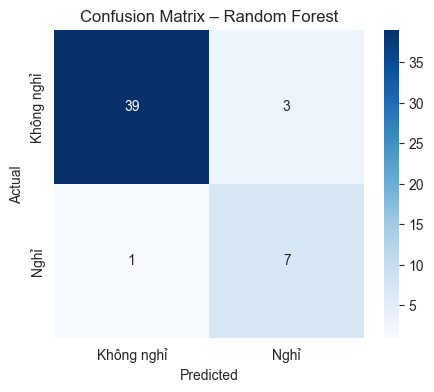

In [86]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_50, y_pred_50)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không nghỉ', 'Nghỉ'],
            yticklabels=['Không nghỉ', 'Nghỉ'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Random Forest')
plt.show()
